# 02 - Análisis Exploratorio de Datos
## Visualización de hábitos y preferencias de películas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
sns.set_style("darkgrid")
os.makedirs('../output', exist_ok=True)

### 2.1 Cargar datos limpios

In [3]:
df = pd.read_csv('../data/processed/movies_clean.csv')
print(f"Total de películas: {len(df)}")
df.head()

Total de películas: 193


,date_rated,title,year,letterboxd_url,my_score
0,2026-04-10,The Marvels,2023,https://boxd.it/mwU4,1.5
1,2026-04-10,Spider-Man,2002,https://boxd.it/2a8i,3.5
2,2026-04-10,Spider-Man 3,2007,https://boxd.it/2a7Y,2.5
3,2026-04-10,Spider-Man 2,2004,https://boxd.it/2a88,4.5
4,2026-04-10,Spider-Man: Into the Spider-Verse,2018,https://boxd.it/azpY,4.5


### 2.2 Distribución de calificaciones

/tmp/ipykernel_1786/183810503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='my_score', data=df, palette='viridis', order=sorted(df['my_score'].unique()))


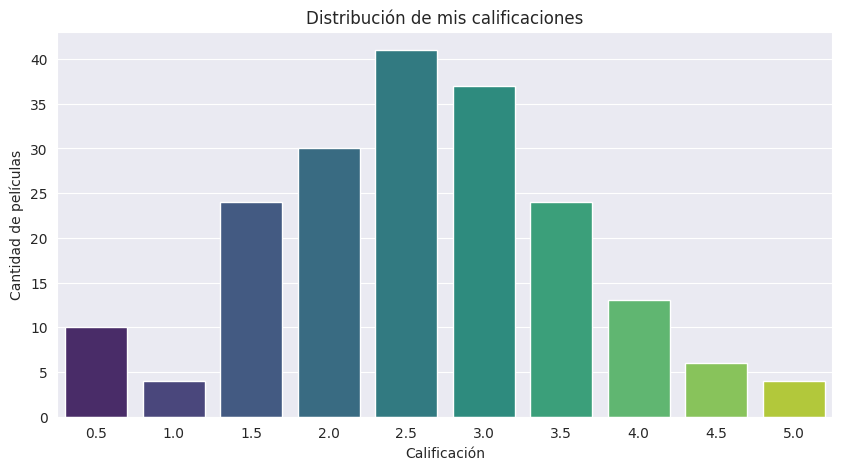

In [4]:
plt.figure(figsize=(10, 5))
sns.countplot(x='my_score', data=df, palette='viridis', order=sorted(df['my_score'].unique()))
plt.title('Distribución de mis calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Cantidad de películas')
plt.savefig('../output/distribucion_calificaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.3 Estadísticas descriptivas

In [5]:
print(f"Calificación promedio: {df['my_score'].mean():.2f}")
print(f"Mediana: {df['my_score'].median()}")
print(f"Desviación estándar: {df['my_score'].std():.2f}")
print(f"Calificación más común (moda): {df['my_score'].mode()[0]}")
print(f"\nPelículas con score 5.0:")
print(df[df['my_score'] == 5.0][['title', 'year']].to_string(index=False))
print(f"\nPelículas con score 4.5:")
print(df[df['my_score'] == 4.5][['title', 'year']].to_string(index=False))

Calificación promedio: 2.60
Mediana: 2.5
Desviación estándar: 1.00
Calificación más común (moda): 2.5

Películas con score 5.0:
                                         title  year
Neon Genesis Evangelion: The End of Evangelion  1997
         Evangelion: 2.0 You Can (Not) Advance  2009
        Evangelion: 3.0+1.0 Thrice Upon a Time  2021
  Berserk: The Golden Age Arc III – The Advent  2013

Películas con score 4.5:
                              title  year
                       Spider-Man 2  2004
  Spider-Man: Into the Spider-Verse  2018
Spider-Man: Across the Spider-Verse  2023
           The Amazing Spider-Man 2  2014
                    The Dark Knight  2008
    Wotakoi: Love Is Hard for Otaku  2018


### 2.4 Películas por década

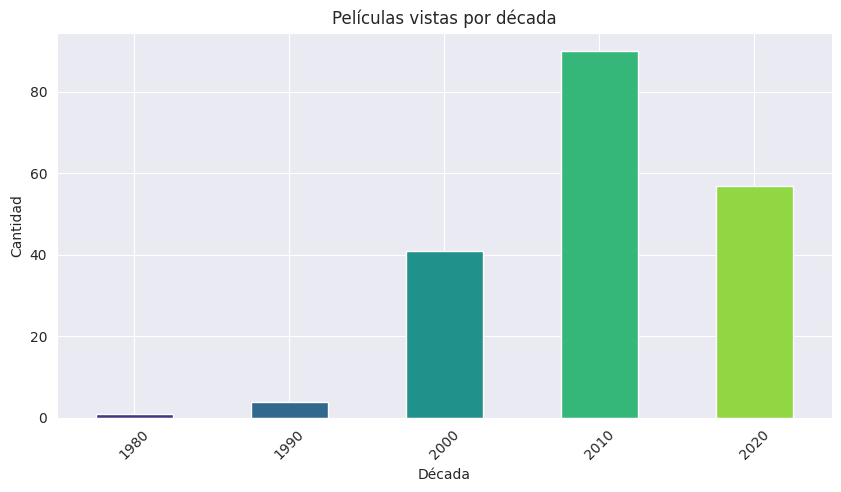

In [6]:
df['decade'] = (df['year'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
decade_counts.plot(kind='bar', color=sns.color_palette('viridis', n_colors=len(decade_counts)))
plt.title('Películas vistas por década')
plt.xlabel('Década')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.savefig('../output/peliculas_por_decada.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.5 Calificación promedio por década

decade
1980    1.500000
1990    3.375000
2000    2.646341
2010    2.627778
2020    2.482456
Name: my_score, dtype: float64


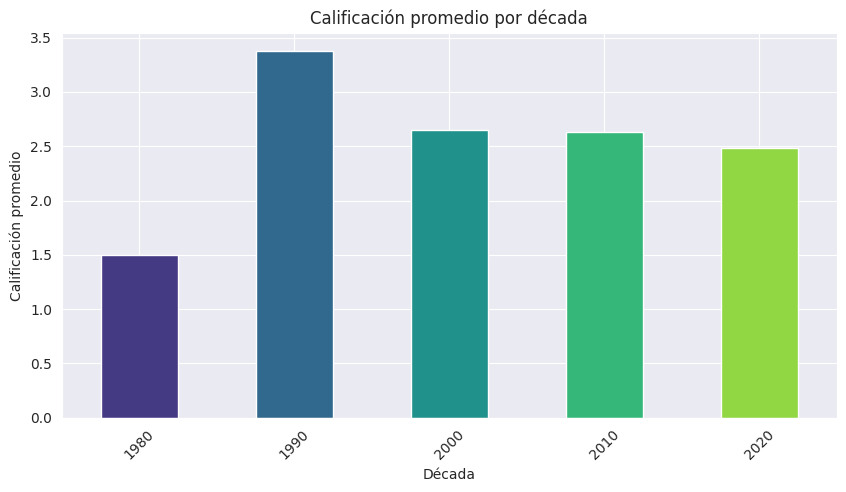

In [7]:
avg_by_decade = df.groupby('decade')['my_score'].mean().sort_index()
print(avg_by_decade)

plt.figure(figsize=(10, 5))
avg_by_decade.plot(kind='bar', color=sns.color_palette('viridis', n_colors=len(avg_by_decade)))
plt.title('Calificación promedio por década')
plt.xlabel('Década')
plt.ylabel('Calificación promedio')
plt.xticks(rotation=45)
plt.savefig('../output/calificacion_por_decada.png', dpi=150, bbox_inches='tight')
plt.show()